# <center> Module 4-3: Regression <br>Support Vector Machine on the GPA Dataset </center>
<center>by: Nicole Woodland, P. Eng. for RoboGarden Inc. </center>

---

In this noteook, we will perform SVM on the GPA dataset. Always start Machine Learning by <b> Asking the Right Question! </b>

<br><center> Can we predict a University grade point average (GPA) for a student based on their High School GPA in a meaningful way? </center>

## Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Read csv file into a dataframe

In [6]:
df = pd.read_csv("../gpa.csv")

In [7]:
df.head(5)

,high_GPA,univ_GPA
0,3.45,3.52
1,2.78,2.91
2,2.52,2.40
3,3.67,3.47
4,3.24,3.47


In [8]:
df.describe()

,high_GPA,univ_GPA
count,105.000000,105.000000
mean,3.076381,3.172857
std,0.516598,0.447194
min,2.030000,2.080000
25%,2.670000,3.010000
50%,3.170000,3.290000
75%,3.480000,3.470000
max,4.000000,3.810000


## Add some new visualizations

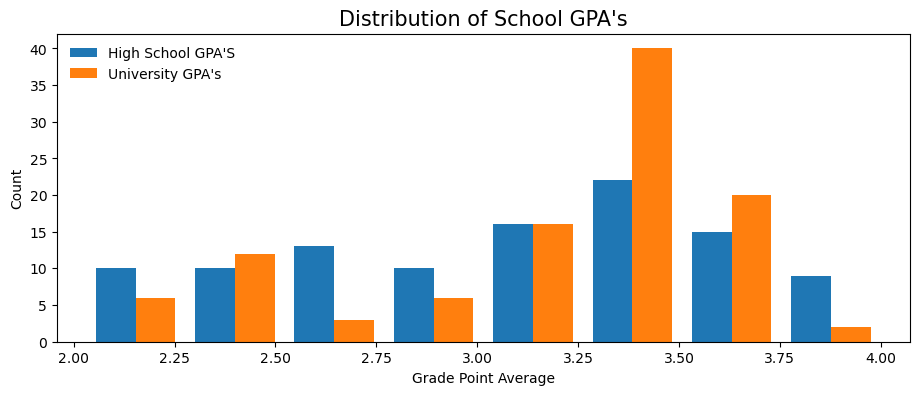

In [10]:
# Could look at the distribution of GPA's on one chart: 
years = ["High School GPA'S", "University GPA's"]

plt.figure(figsize=(11,4))
plt.hist(df, label = years,  bins = 8)
plt.title("Distribution of School GPA's", size = 15)
plt.xlabel("Grade Point Average")
plt.ylabel("Count")
plt.legend(loc='upper left', frameon=False)
plt.show()

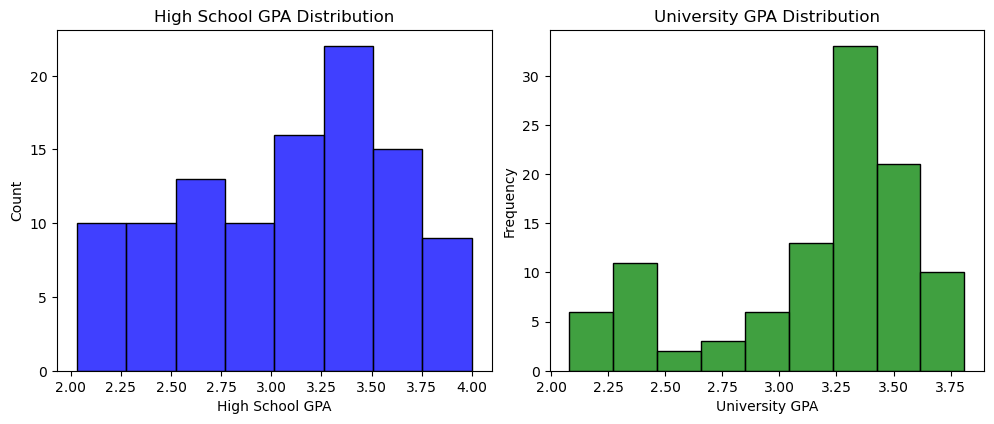

In [11]:
# OR view histograms side by side to see the distribution of grades
fig1, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))
fig1.tight_layout()

sn.histplot(df["high_GPA"], bins = "auto", color = "blue", ax = ax1)
ax1.set_ylabel("Count")
ax1.set_xlabel("High School GPA")
ax1.set_title("High School GPA Distribution")

sn.histplot(df["univ_GPA"], bins="auto", color='green', ax = ax2 )
ax2.set_title("University GPA Distribution")
ax2.set_xlabel("University GPA")
ax2.set_ylabel("Frequency")

fig1.show()

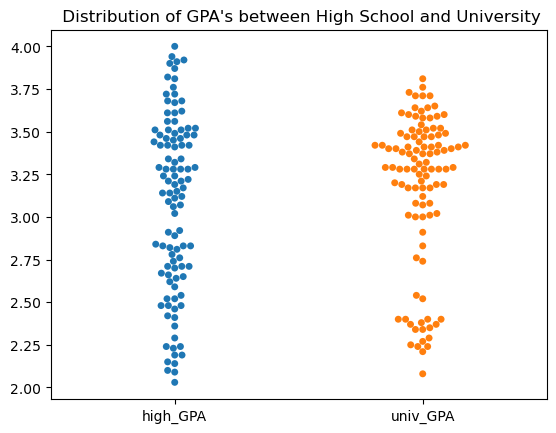

In [12]:
# Or in a totally different way! Swarmplots are similar to Box and Violin plots
sn.swarmplot(df)
plt.title(" Distribution of GPA's between High School and University")
plt.show()

## Create Input and Output Data

In [14]:
X = df.iloc[:,0:1].values
y = df.iloc[:,1:2].values

## Create Train and Test Sets

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    random_state=1)

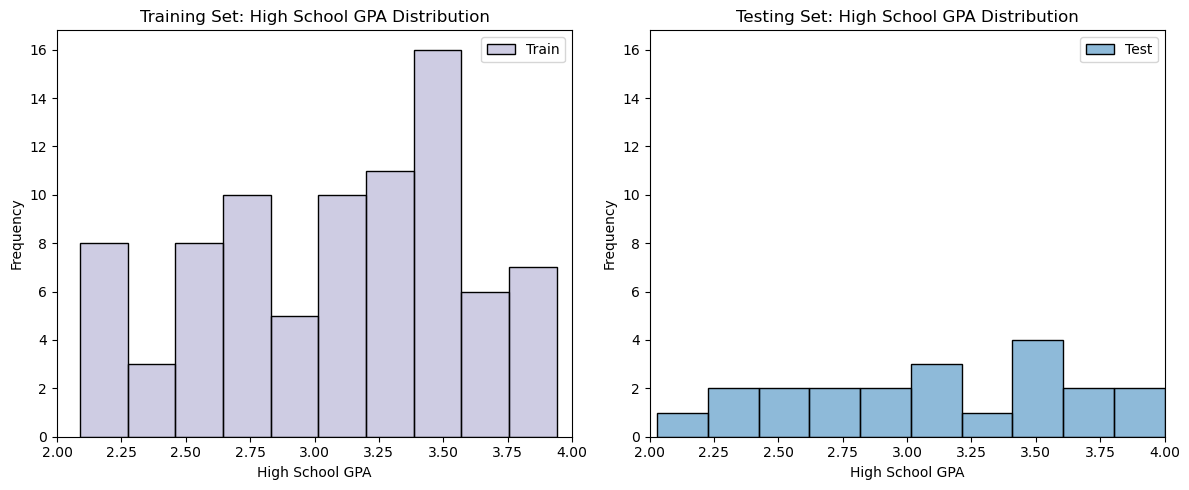

In [59]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))  # 1 row, 2 columns

# Plot Training Data Histogram (Target Variable)
sn.histplot(X_train, bins=10, ax=ax1, label="Train", palette = "Purples")
ax1.set_title("Training Set: High School GPA Distribution")
ax1.set_xlabel("High School GPA")
ax1.set_ylabel("Frequency")
ax1.legend()

# Plot Testing Data Histogram (Target Variable)
sn.histplot(X_test, color = "black",bins=10, ax=ax2, label="Test")
ax2.set_title("Testing Set: High School GPA Distribution")
ax2.set_xlabel("High School GPA")
ax2.set_ylabel("Frequency")
ax2.legend()

# Ensure both subplots have the same x and y axis limits
x_min, x_max = 2, 4
y_min, y_max = 0, max(ax1.get_ylim()[1], ax2.get_ylim()[1])  # Get max y-limit from both plots
ax1.set_xlim(x_min, x_max)
ax2.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

## Support Vector Machine Modelling

### Train a Linear SVR Model

In [61]:
from sklearn.svm import SVR
modelSVR = SVR(kernel='linear').fit(X_train, y_train)
y_pred = modelSVR.predict(X_test)

### Evaluate the SVR model

In [22]:
scoreSVRlinear = modelSVR.score(X_test, y_test).round(3)
print(scoreSVRlinear)

0.477


In [23]:
from sklearn.metrics import mean_squared_error

y_pred = modelSVR.predict(X_test)
mean_squared_error(y_test, y_pred)

0.09847506308550066

In [24]:
from sklearn.metrics import mean_absolute_error

y_pred = modelSVR.predict(X_test)
mean_absolute_error(y_test, y_pred)

0.2222526132718024

### Visualize the Relationship

*Note this is possible with simple code because only 1 X and 1 y

In [26]:
X_sorted = np.sort(X_train, axis = 0)

In [27]:
X_sorted

array([[2.03],
       [2.14],
       [2.15],
       [2.19],
       [2.24],
       [2.24],
       [2.29],
       [2.36],
       [2.41],
       [2.42],
       [2.46],
       [2.48],
       [2.48],
       [2.48],
       [2.52],
       [2.54],
       [2.59],
       [2.62],
       [2.64],
       [2.65],
       [2.67],
       [2.7 ],
       [2.71],
       [2.71],
       [2.71],
       [2.74],
       [2.76],
       [2.78],
       [2.83],
       [2.84],
       [2.89],
       [2.91],
       [2.92],
       [3.06],
       [3.07],
       [3.09],
       [3.11],
       [3.12],
       [3.14],
       [3.15],
       [3.17],
       [3.19],
       [3.21],
       [3.21],
       [3.22],
       [3.24],
       [3.28],
       [3.28],
       [3.28],
       [3.28],
       [3.29],
       [3.29],
       [3.32],
       [3.34],
       [3.34],
       [3.41],
       [3.42],
       [3.42],
       [3.45],
       [3.46],
       [3.46],
       [3.48],
       [3.48],
       [3.48],
       [3.51],
       [3.51],
       [3.

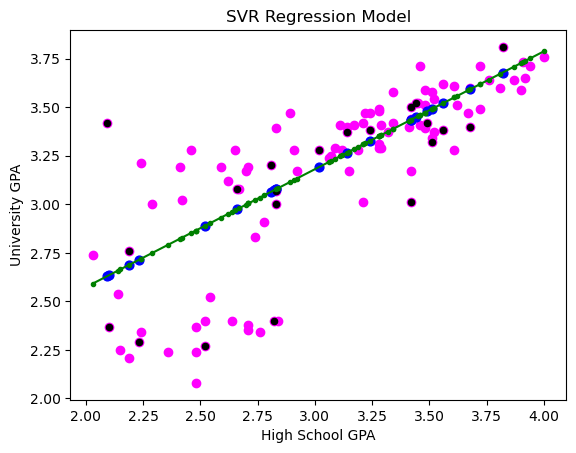

In [28]:
# Plot the provided points
plt.scatter(X, y, color = 'magenta')
predictionsLinear = modelSVR.predict(X_sorted)

# Draw a line based on the predicted values of X_train
plt.plot(X_sorted, predictionsLinear, color = 'green', marker = ".") 

# Compare with the Test Points
plt.scatter(X_test, y_pred, color = 'blue', s = 40)
plt.scatter(X_test, y_test, color = 'black', s = 20)

# Add details
plt.title('SVR Regression Model')
plt.xlabel('High School GPA')
plt.ylabel('University GPA')
plt.show()

## Train a Polynomial SVR Model

In [75]:
deg = list(range(1,5))
scoresSVRpoly = []

for i in deg:
    modelSVRpoly = SVR(kernel='poly',
                       degree=i,
                       gamma='auto', 
                       tol = 0.001,
                       max_iter = 10000).fit(X_train, y_train)

    score = modelSVRpoly.score(X_test, y_test)
    scoresSVRpoly.append(score)
    print(i, 'gives a score of: ',score) 

scoreSVRpoly = max(scoresSVRpoly)
bestSVRPoly = scoresSVRpoly.index(max(scoresSVRpoly)) + 1 # location of max score

print('SVR Polynomial Regression gives a best score of:', 
      scoreSVRpoly, "with a degree of",bestSVRPoly )  

1 gives a score of:  0.45163342420805674
2 gives a score of:  0.49493317342049425
3 gives a score of:  0.4962943499206449
4 gives a score of:  0.45664878604274484
SVR Polynomial Regression gives a best score of: 0.4962943499206449 with a degree of 3


## Visualize an SVR Model

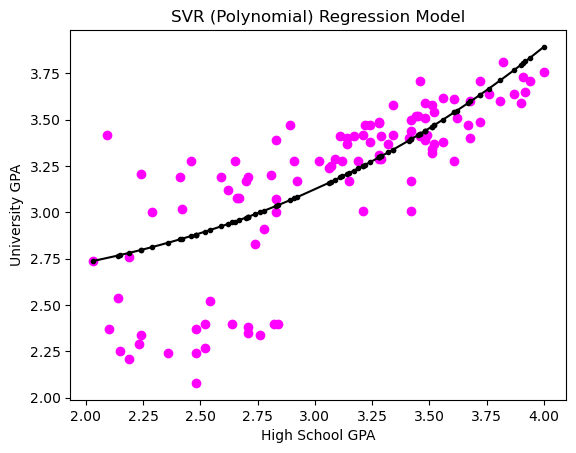

In [77]:
# Retrain the degree = 2 polynomial model for comparison:
modelBestSVRpoly = SVR(kernel='poly',
                       degree=3, 
                       gamma='auto',
                       tol = 0.001,
                       max_iter = 100000).fit(X_train, y_train)

# Plot the provided points
plt.scatter(X, y, color = 'magenta')
predictionsPoly = modelBestSVRpoly.predict(X_sorted)
scoreSVRpoly = modelBestSVRpoly.score(X_test, y_test).round(3)

# Draw a line based on the predicted values of X_train
plt.plot(X_sorted, predictionsPoly, color = 'black', marker = ".") 


# Add details
plt.title('SVR (Polynomial) Regression Model')
plt.xlabel('High School GPA')
plt.ylabel('University GPA')
plt.show()

### Train an RBF SVR Model

In [79]:
# Train an RBF model for comparison:
modelRBF = SVR(kernel='rbf', 
               gamma='auto',
               tol = 0.001,
               C = 1.5,
               max_iter = 100000,).fit(X_train, y_train)

0.377


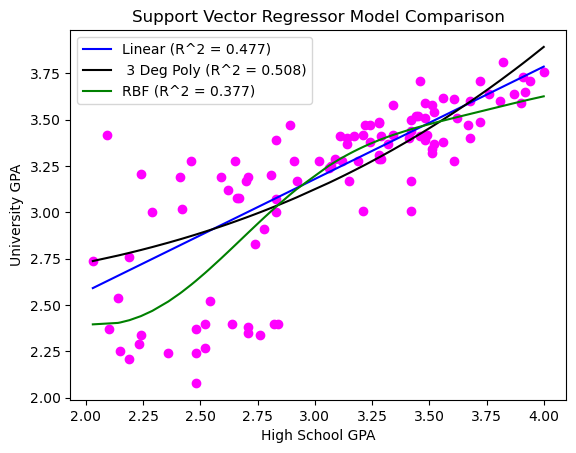

In [83]:
scoreSVRrbf = modelRBF.score(X_test, y_test).round(3)
print(scoreSVRrbf)

# Plot the provided points
plt.scatter(X, y, color = 'magenta')
predictionsRBF = modelRBF.predict(X_sorted)
 

# Draw all three "models" based on the predicted values of X_train
plt.plot(X_sorted, predictionsLinear, color = 'blue', label = f"Linear (R^2 = {scoreSVRlinear})")
plt.plot(X_sorted, predictionsPoly, color = 'black', label = f" 3 Deg Poly (R^2 = {scoreSVRpoly})")
plt.plot(X_sorted, predictionsRBF, color = 'green', label = f"RBF (R^2 = {scoreSVRrbf})") 
plt.legend()

# Add details
plt.title('Support Vector Regressor Model Comparison')
plt.xlabel('High School GPA')
plt.ylabel('University GPA')
plt.show()